# GTEx


In [17]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import specificity_metrics

import importlib
import functions
import auxillary_plots
import constants
importlib.reload(constants)
importlib.reload(auxillary_plots)
importlib.reload(functions)
from constants import *

pd.set_option(
    "display.float_format",
    lambda x: f"{x:.2e}" if abs(x) < 0.01 else f"{x:.3f}"
)

print(f'Specificity metric: {SPECIFICITY_METRIC}')
print(f'Specificity threshold: {SPECIFICITY_THR}')
print(f'Figure mode: {FIG_MODE}')

print("PROJ_ROOT:", PROJ_ROOT)


Specificity metric: Tau
Specificity threshold: 0.8
Figure mode: pdf
PROJ_ROOT: /Users/neuropromotion/Desktop/miRNA/bulk_review


In [18]:
gtex_loader = functions.Load_GTEx_Data(PATH_GTEX_COUNTS, PATH_GTEX_META)

In [19]:
lin_df, specificity_gtex_df = gtex_loader.run_pipeline()

Samples in meta: 16004 | after SMTSD ≥ 10 : 15998
Number of eligible SMTSD: 26
counts dataframe size (samples × miRNA): (15998, 604)
with SMTS: 15998
Running Tau score, per SMTSD, log2(CPM+1) [log_of_mean]...


In [20]:
lin_df_grouped = gtex_loader.agregate(lin_df)
specificity_gtex_df["gtex_tissues"] = specificity_gtex_df.apply(
    lambda row: functions.get_top_tissues_expression(row, lin_df_grouped, threshold=0),
    axis=1,
)

In [21]:
specificity_gtex_df

,mature_name,Tau_gtex,gtex_tissues
0,hsa-mir-216a-3p,0.997,"Pancreas [0.98], Testis [0.00], Brain [0.00]"
1,hsa-mir-3663-5p,0.997,"Testis [0.97], Brain [0.02], Adrenal Gland [0.00]"
2,hsa-mir-372-5p,0.996,"Testis [0.94], Heart [0.03], Breast [0.01]"
3,hsa-mir-526b-3p,0.993,"Testis [0.93], Breast [0.02], Omentum [0.01]"
4,hsa-mir-515-3p,0.993,"Testis [0.90], Omentum [0.02], Spleen [0.02]"
...,...,...,...
599,hsa-mir-27b-3p,0.087,"Mucosa [0.08], Heart [0.07], Kidney [0.06]"
600,hsa-mir-24-3p,0.080,"Heart [0.07], Skin [0.07], Lung [0.07]"
601,hsa-mir-100-5p,0.080,"Thyroid [0.07], Ovary [0.07], Fallopian Tube [..."
602,hsa-mir-28-3p,0.071,"Whole Blood [0.07], Spleen [0.06], Adrenal Gla..."


In [22]:
specificity_gtex_df.to_csv(TAB_OUT / f'{SPECIFICITY_METRIC}_gtex.csv')

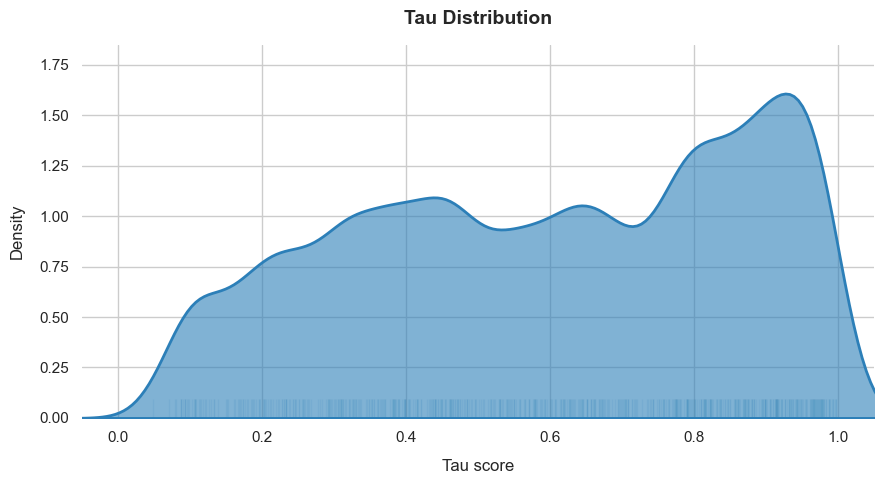

In [23]:
auxillary_plots.plot_specificity_distribution(specificity_gtex_df, 
                    f'{SPECIFICITY_METRIC}_gtex', 
                    save_path= FIG_OUT / f'{SPECIFICITY_METRIC}_distributions_GTEX.{FIG_MODE}')

Samples in meta: 16004 | after SMTSD ≥ 10 : 15998
Number of eligible SMTSD: 26
counts dataframe size (samples × miRNA): (15998, 604)
with SMTS: 15998


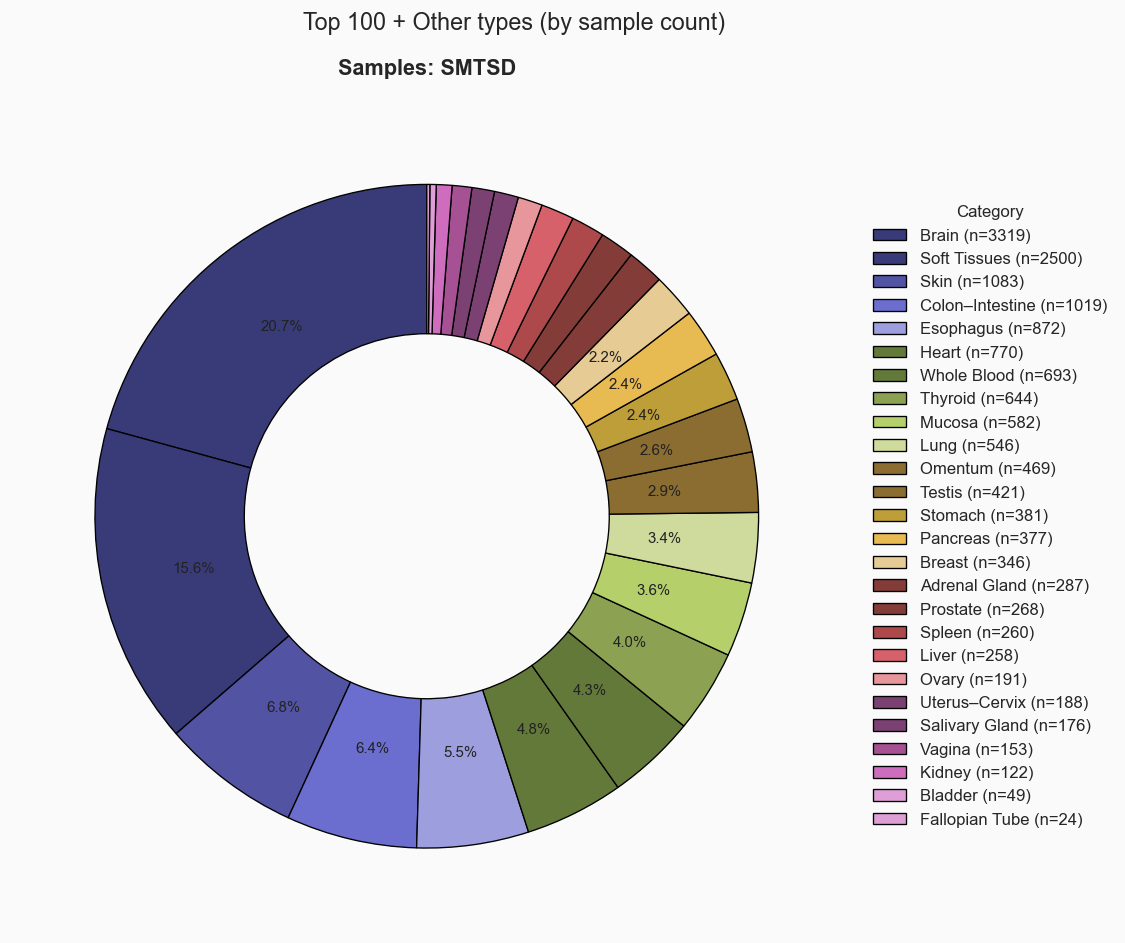

In [24]:
gtex_loader.plot_pie(save_path = FIG_OUT / f'gtex_pie.{FIG_MODE}')